In [ ]:
!pip install opencv-python-headless matplotlib numpy requests pillow

print("✅ Librerías instaladas")

✅ Librerías instaladas


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO

print("✅ Librerías listas")

✅ Librerías listas


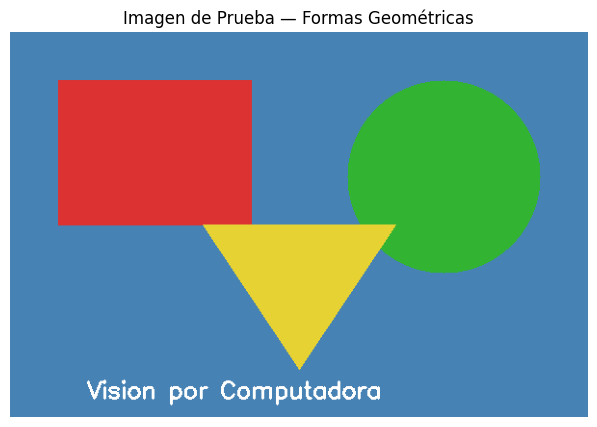

✅ Imagen creada: (400, 600, 3)


In [ ]:
# Creamos una imagen de prueba directamente sin descargar nada
imagen = np.zeros((400, 600, 3), dtype=np.uint8)

# Fondo azul
imagen[:] = (70, 130, 180)

# Rectángulo rojo
cv2.rectangle(imagen, (50, 50), (250, 200), (220, 50, 50), -1)

# Círculo verde
cv2.circle(imagen, (450, 150), 100, (50, 180, 50), -1)

# Triángulo amarillo
pts = np.array([[300, 350], [200, 200], [400, 200]], np.int32)
cv2.fillPoly(imagen, [pts], (230, 210, 50))

# Texto
cv2.putText(imagen, "Vision por Computadora", (80, 380),
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

plt.figure(figsize=(8, 5))
plt.imshow(imagen)
plt.title("Imagen de Prueba — Formas Geométricas")
plt.axis('off')
plt.show()

print(f"✅ Imagen creada: {imagen.shape}")

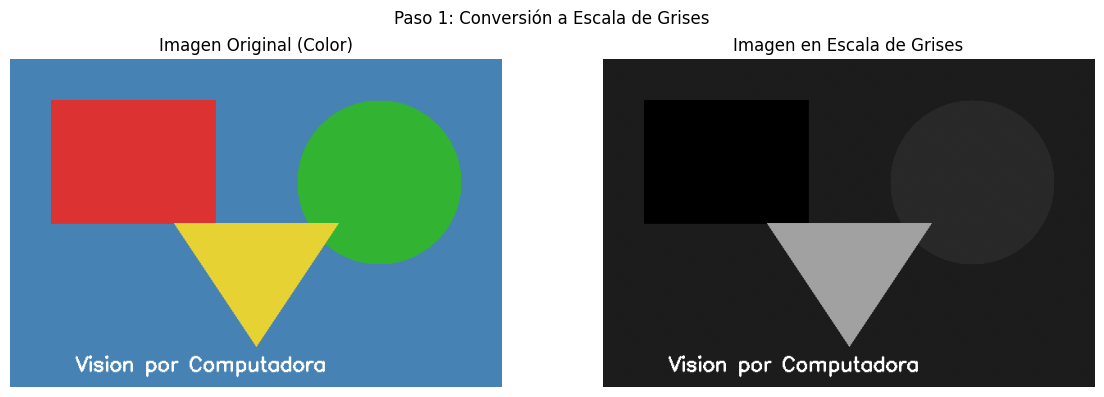

In [ ]:
# Convertir a escala de grises
gris = cv2.cvtColor(imagen, cv2.COLOR_RGB2GRAY)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(imagen)
axes[0].set_title("Imagen Original (Color)")
axes[0].axis('off')

axes[1].imshow(gris, cmap='gray')
axes[1].set_title("Imagen en Escala de Grises")
axes[1].axis('off')

plt.suptitle("Paso 1: Conversión a Escala de Grises")
plt.tight_layout()
plt.show()

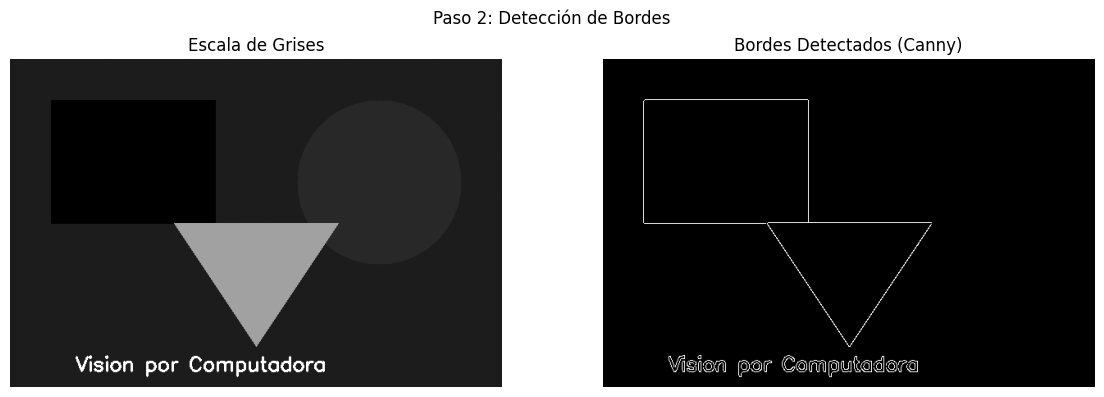

In [ ]:
# Aplicar detector de bordes Canny
bordes = cv2.Canny(gris, threshold1=50, threshold2=150)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(gris, cmap='gray')
axes[0].set_title("Escala de Grises")
axes[0].axis('off')

axes[1].imshow(bordes, cmap='gray')
axes[1].set_title("Bordes Detectados (Canny)")
axes[1].axis('off')

plt.suptitle("Paso 2: Detección de Bordes")
plt.tight_layout()
plt.show()

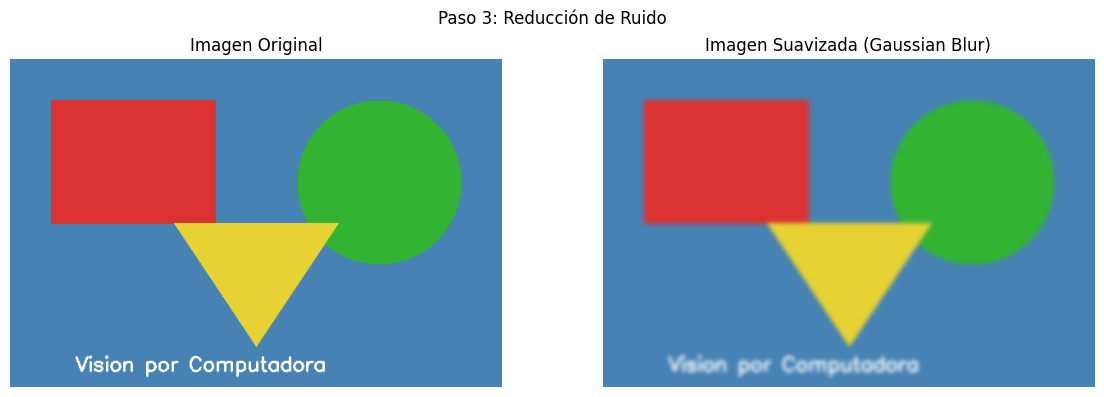

In [ ]:
# Aplicar desenfoque gaussiano para reducir ruido
suavizado = cv2.GaussianBlur(imagen, (15, 15), 0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(imagen)
axes[0].set_title("Imagen Original")
axes[0].axis('off')

axes[1].imshow(suavizado)
axes[1].set_title("Imagen Suavizada (Gaussian Blur)")
axes[1].axis('off')

plt.suptitle("Paso 3: Reducción de Ruido")
plt.tight_layout()
plt.show()

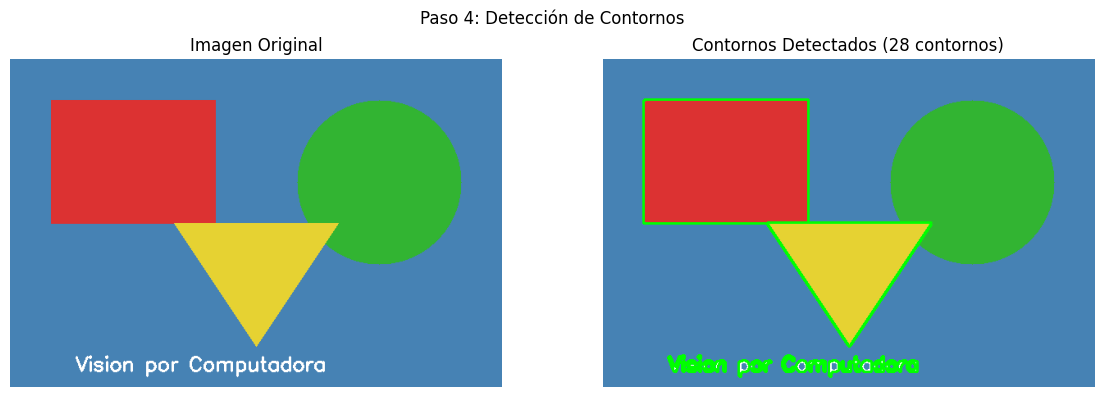

✅ Total de contornos detectados: 28


In [ ]:
# Detectar contornos en la imagen
contornos, _ = cv2.findContours(bordes, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Dibujar contornos sobre la imagen original
imagen_contornos = imagen.copy()
cv2.drawContours(imagen_contornos, contornos, -1, (0, 255, 0), 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(imagen)
axes[0].set_title("Imagen Original")
axes[0].axis('off')

axes[1].imshow(imagen_contornos)
axes[1].set_title(f"Contornos Detectados ({len(contornos)} contornos)")
axes[1].axis('off')

plt.suptitle("Paso 4: Detección de Contornos")
plt.tight_layout()
plt.show()

print(f"✅ Total de contornos detectados: {len(contornos)}")

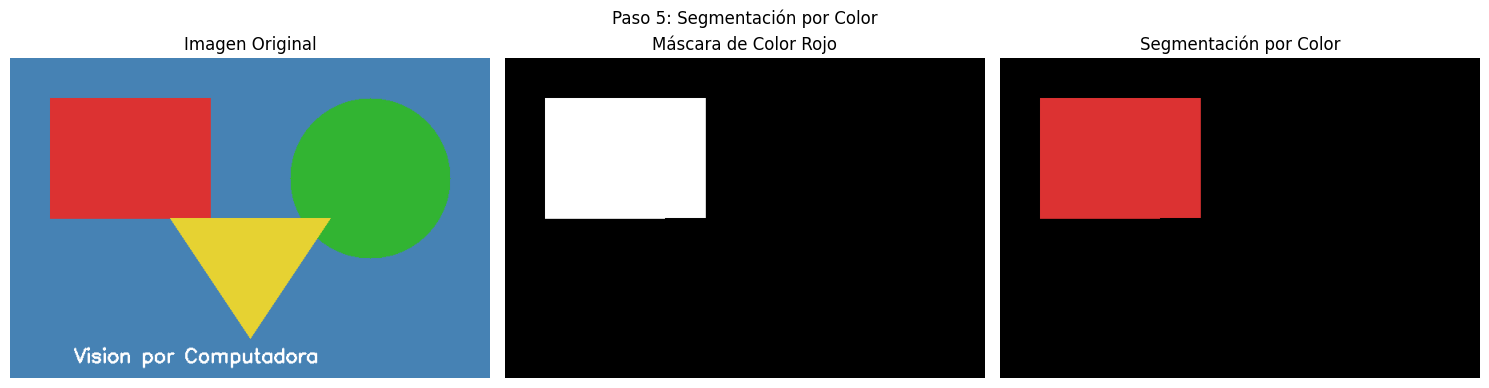

In [ ]:
# Convertir a HSV para segmentar por color
hsv = cv2.cvtColor(imagen, cv2.COLOR_RGB2HSV)

# Definir rango de color rojo
bajo_rojo = np.array([0, 100, 100])
alto_rojo = np.array([10, 255, 255])

# Crear máscara
mascara = cv2.inRange(hsv, bajo_rojo, alto_rojo)
segmentado = cv2.bitwise_and(imagen, imagen, mask=mascara)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(imagen)
axes[0].set_title("Imagen Original")
axes[0].axis('off')

axes[1].imshow(mascara, cmap='gray')
axes[1].set_title("Máscara de Color Rojo")
axes[1].axis('off')

axes[2].imshow(segmentado)
axes[2].set_title("Segmentación por Color")
axes[2].axis('off')

plt.suptitle("Paso 5: Segmentación por Color")
plt.tight_layout()
plt.show()

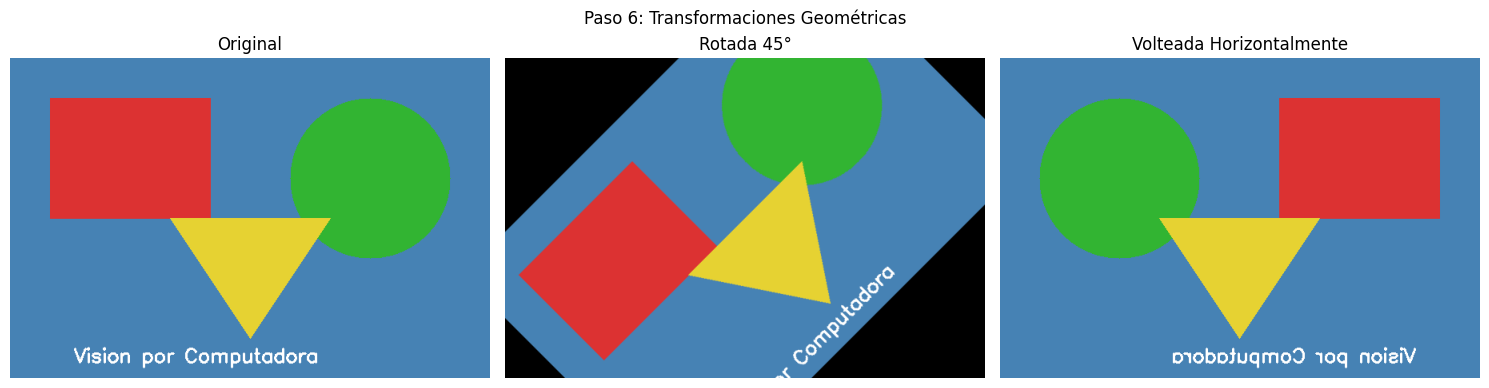

In [ ]:
alto, ancho = imagen.shape[:2]

# Rotar imagen 45 grados
centro = (ancho // 2, alto // 2)
matriz_rotacion = cv2.getRotationMatrix2D(centro, 45, 1.0)
rotada = cv2.warpAffine(imagen, matriz_rotacion, (ancho, alto))

# Voltear imagen horizontalmente
volteada = cv2.flip(imagen, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(imagen)
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(rotada)
axes[1].set_title("Rotada 45°")
axes[1].axis('off')

axes[2].imshow(volteada)
axes[2].set_title("Volteada Horizontalmente")
axes[2].axis('off')

plt.suptitle("Paso 6: Transformaciones Geométricas")
plt.tight_layout()
plt.show()

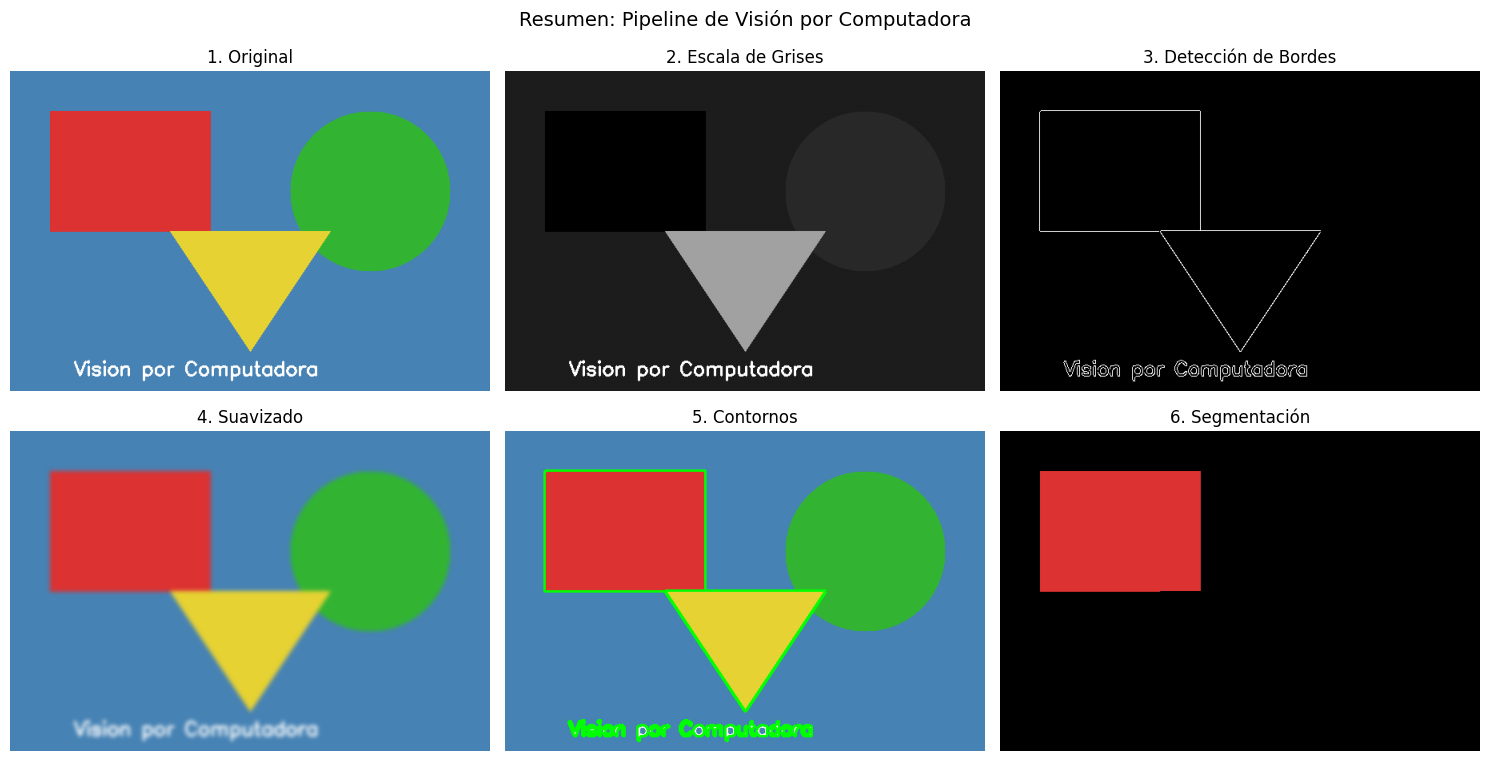

✅ Pipeline completo de visión por computadora finalizado


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].imshow(imagen)
axes[0, 0].set_title("1. Original")
axes[0, 0].axis('off')

axes[0, 1].imshow(gris, cmap='gray')
axes[0, 1].set_title("2. Escala de Grises")
axes[0, 1].axis('off')

axes[0, 2].imshow(bordes, cmap='gray')
axes[0, 2].set_title("3. Detección de Bordes")
axes[0, 2].axis('off')

axes[1, 0].imshow(suavizado)
axes[1, 0].set_title("4. Suavizado")
axes[1, 0].axis('off')

axes[1, 1].imshow(imagen_contornos)
axes[1, 1].set_title("5. Contornos")
axes[1, 1].axis('off')

axes[1, 2].imshow(segmentado)
axes[1, 2].set_title("6. Segmentación")
axes[1, 2].axis('off')

plt.suptitle("Resumen: Pipeline de Visión por Computadora", fontsize=14)
plt.tight_layout()
plt.show()

print("✅ Pipeline completo de visión por computadora finalizado")